In [1]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=64)
dataset = BNCI2014009()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/usr/local/lib/python3.10/dist-packages/moabb/datasets/download.py:55: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

nfreqs=16

X = epochs.get_data()
X = tl.tensor(X)
y = labels

print(X.shape)
print(X.dtype)
print(X.device)

(576, 16, 52)
float32
<CUDA Device 0>


AttributeError: 'ndarray' object has no attribute 'context'

In [8]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[4]*16,
    hoda_params=dict(
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X,y)

Fitting block 1/16...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 2/16...


  0%|          | 0/256 [00:00<?, ?it/s]

...

Fitting block 16/16...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

CPU times: user 23 s, sys: 251 ms, total: 23.3 s
Wall time: 23.6 s


BTTDA(extra_train_info=True,
      hoda_params={'extra_train_info': False, 'forward': True, 'init': 'random',
                   'max_iter': 256, 'obj': 'rt', 'random_state': 42, 'rank': 4,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': True,
                   'toeplitz': None, 'tol': 1e-12, 'verbose': True},
      ranks=[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], verbose=True)

In [9]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,mse,F_tr,F_rt
0,1,"(4, 4)",0.924121,0.304909,0.009655
1,2,"(4, 4)",0.820554,0.230213,0.011145
2,3,"(4, 4)",0.796104,0.207025,0.012995
3,4,"(4, 4)",0.772928,0.199134,0.013583
4,5,"(4, 4)",0.747950,0.183934,0.014670
5,6,"(4, 4)",0.712840,0.174912,0.015400
6,7,"(4, 4)",0.673648,0.167183,0.015827
7,8,"(4, 4)",0.637665,0.161781,0.016299
8,9,"(4, 4)",0.626209,0.156630,0.017245
9,10,"(4, 4)",0.600878,0.150868,0.017557


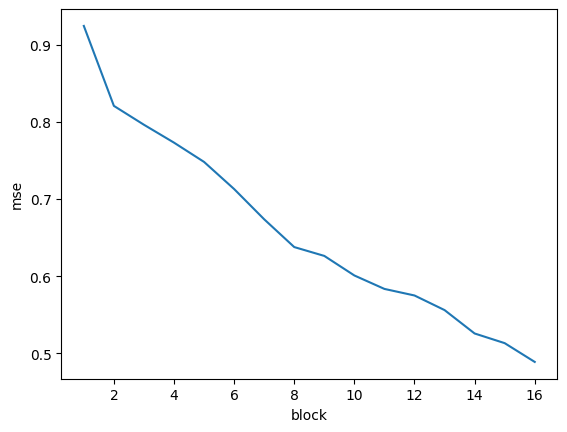

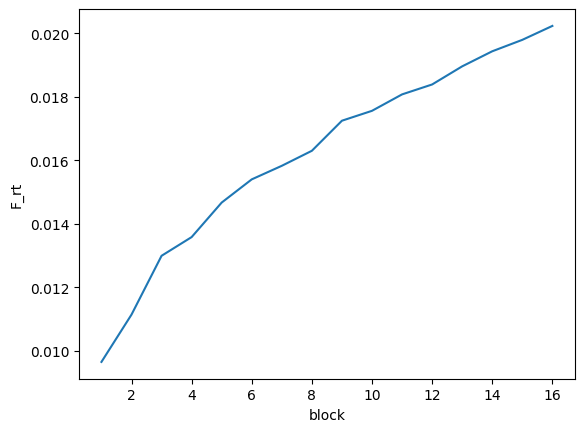

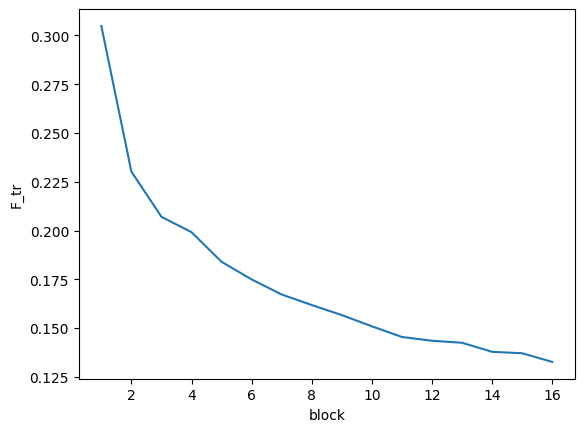

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='mse')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_tr')

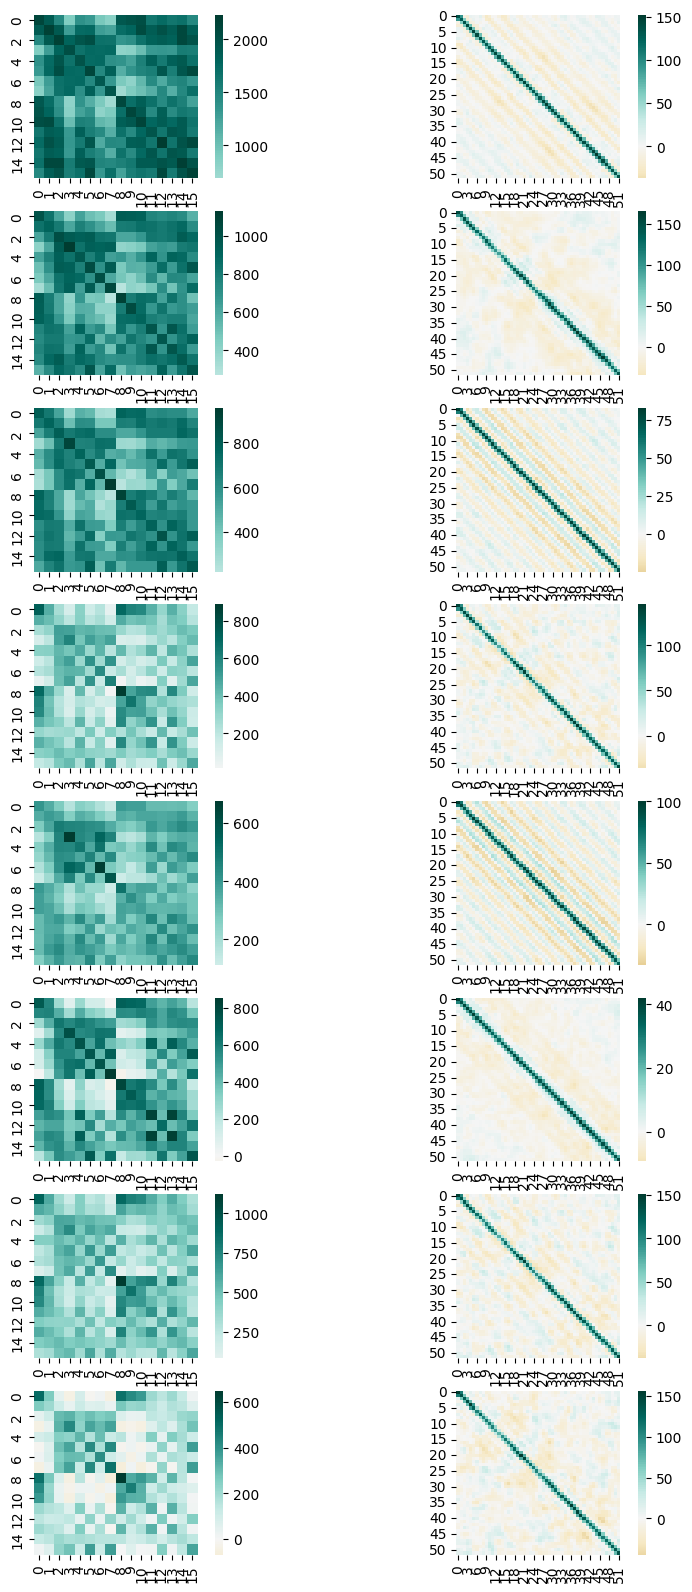

In [11]:
fig, axs = plt.subplots(min(bttda.n_blocks_,8),2, figsize=(10,20))
for b in range(min(bttda.n_blocks_,8)):
    for k in range(2):
        scatter = bttda.blocks_[b].scatter_w_[k]
        scatter = tl.to_numpy(scatter)
        sns.heatmap(scatter, ax=axs[b,k], square=True, center=0, cmap='BrBG')

In [17]:
Xt = tl.to_numpy(bttda.transform(X))

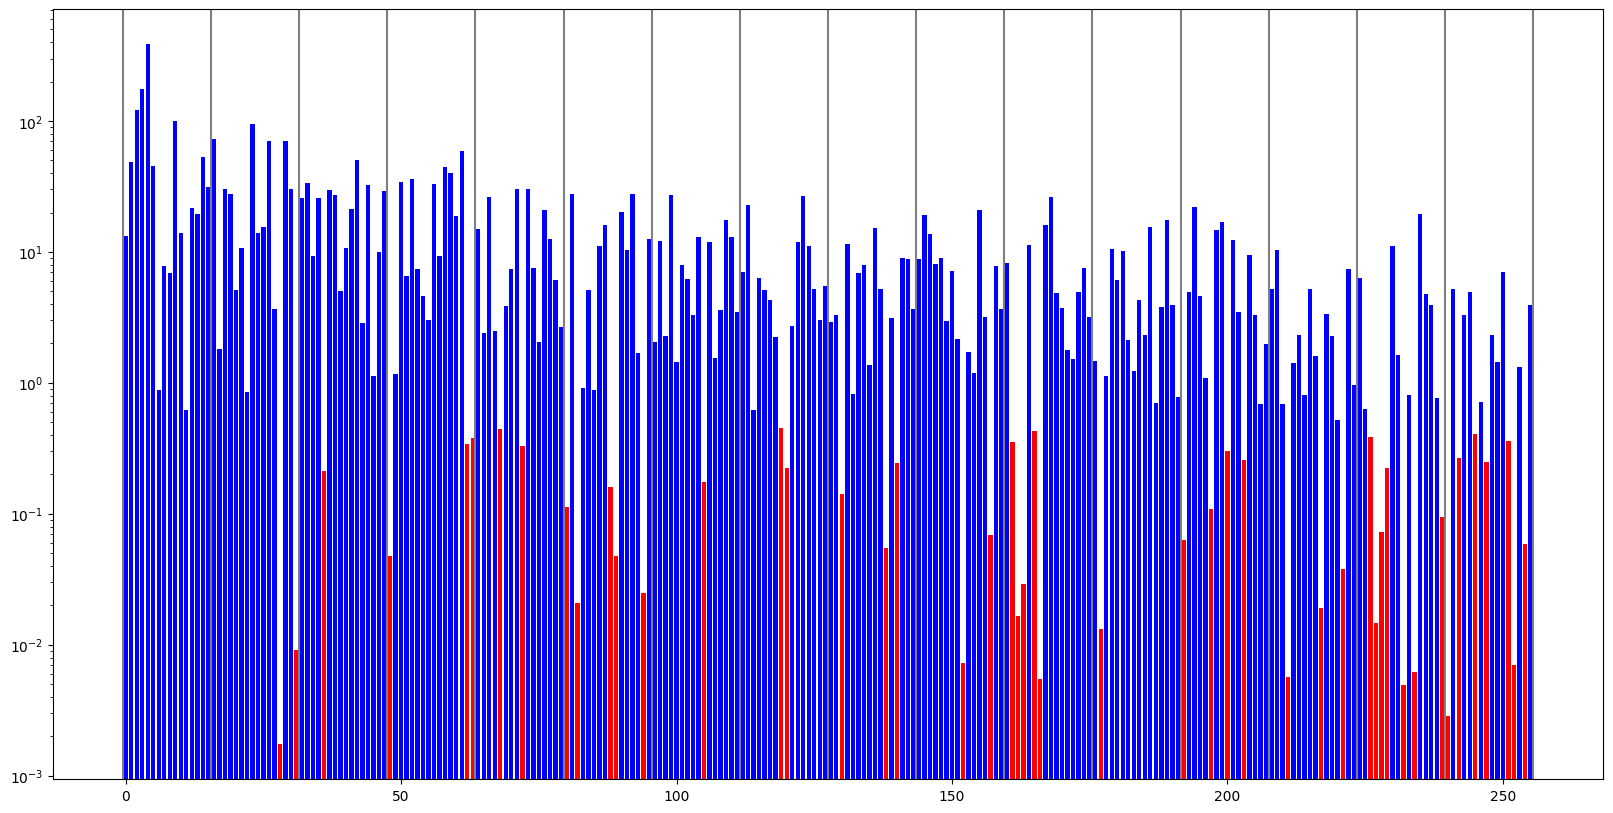

In [18]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)

alpha=0.5
sig_idc = p < alpha

fig, ax = plt.subplots(1,1, figsize=(20,10))
ax.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
ax.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
ax.set_yscale('log')
n_params=0
ax.axvline(n_params-.5, color='grey')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    ax.axvline(n_params-.5, color='grey')


<Axes: >

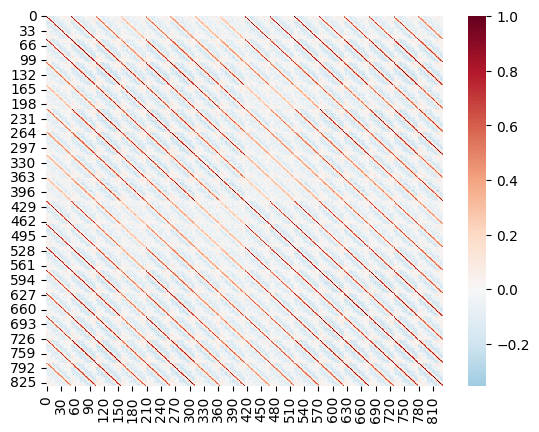

In [14]:
sns.heatmap(np.corrcoef(tl.to_numpy(X.reshape((n_samples, -1))), rowvar=False),  cmap='RdBu_r', center=0)

<Axes: >

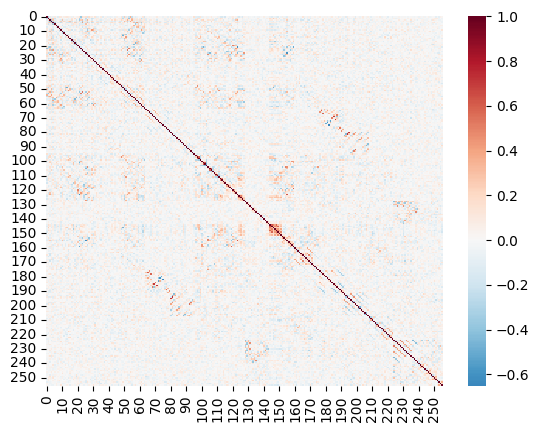

In [15]:
sns.heatmap(np.corrcoef(tl.to_numpy(Xt), rowvar=False),  cmap='RdBu_r', center=0)

In [16]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

NameError: name 'Xt_flat' is not defined

In [ ]:
 import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

In [ ]:
from mne import EvokedArray
for b in bttda.blocks_[:8]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)